In [5]:
import pandas as pd

df = pd.read_csv("../data/raw/smart_manufacturing_data.csv")

In [2]:
df.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   timestamp                 100000 non-null  str    
 1   machine_id                100000 non-null  int64  
 2   temperature               100000 non-null  float64
 3   vibration                 100000 non-null  float64
 4   humidity                  100000 non-null  float64
 5   pressure                  100000 non-null  float64
 6   energy_consumption        100000 non-null  float64
 7   machine_status            100000 non-null  int64  
 8   anomaly_flag              100000 non-null  int64  
 9   predicted_remaining_life  100000 non-null  int64  
 10  failure_type              100000 non-null  str    
 11  downtime_risk             100000 non-null  float64
 12  maintenance_required      100000 non-null  int64  
dtypes: float64(6), int64(5), str(2)
memory usage: 12.4 MB


In [4]:
df.columns

Index(['timestamp', 'machine_id', 'temperature', 'vibration', 'humidity',
       'pressure', 'energy_consumption', 'machine_status', 'anomaly_flag',
       'predicted_remaining_life', 'failure_type', 'downtime_risk',
       'maintenance_required'],
      dtype='str')

In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   timestamp                 100000 non-null  datetime64[us]
 1   machine_id                100000 non-null  int64         
 2   temperature               100000 non-null  float64       
 3   vibration                 100000 non-null  float64       
 4   humidity                  100000 non-null  float64       
 5   pressure                  100000 non-null  float64       
 6   energy_consumption        100000 non-null  float64       
 7   machine_status            100000 non-null  int64         
 8   anomaly_flag              100000 non-null  int64         
 9   predicted_remaining_life  100000 non-null  int64         
 10  failure_type              100000 non-null  str           
 11  downtime_risk             100000 non-null  float64       
 12  maintenance_re

In [8]:
df.describe()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,downtime_risk,maintenance_required
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2025-02-04 17:19:30,25.499330,75.015625,50.012270,54.995401,3.000405,2.747064,1.002050,0.089160,234.269160,0.089155,0.196970
min,2025-01-01 00:00:00,1.000000,35.550000,-17.090000,30.000000,1.000000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2025-01-18 08:39:45,13.000000,68.267500,39.970000,42.520000,2.000000,1.630000,1.000000,0.000000,97.000000,0.000000,0.000000
50%,2025-02-04 17:19:30,25.000000,75.060000,49.960000,54.980000,3.010000,2.740000,1.000000,0.000000,230.000000,0.000000,0.000000
75%,2025-02-22 01:59:15,38.000000,81.750000,60.100000,67.500000,4.000000,3.870000,1.000000,0.000000,365.000000,0.000000,0.000000
max,2025-03-11 10:39:00,50.000000,121.940000,113.800000,80.000000,5.000000,5.000000,2.000000,1.000000,499.000000,1.000000,1.000000
std,NaN,14.389439,10.031884,14.985444,14.437960,1.152399,1.297865,0.446193,0.284976,150.063062,0.284961,0.397711


In [9]:
df["anomaly_flag"].value_counts()

anomaly_flag
0    91084
1     8916
Name: count, dtype: int64

In [10]:
df["failure_type"].value_counts()

failure_type
Normal              91899
Vibration Issue      3129
Overheating          1989
Pressure Drop        1969
Electrical Fault     1014
Name: count, dtype: int64

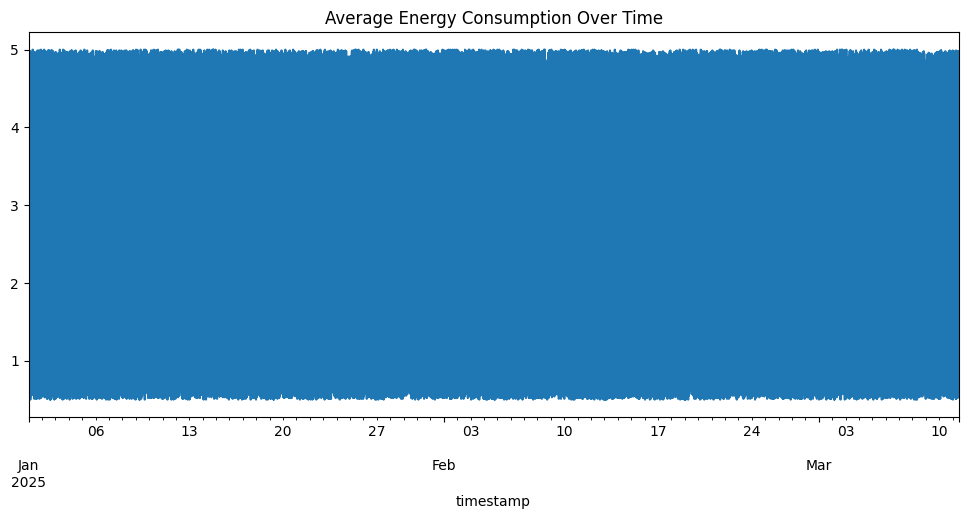

In [11]:
import matplotlib.pyplot as plt

df.groupby("timestamp")["energy_consumption"].mean().plot(figsize=(12,5))

plt.title("Average Energy Consumption Over Time")
plt.show()

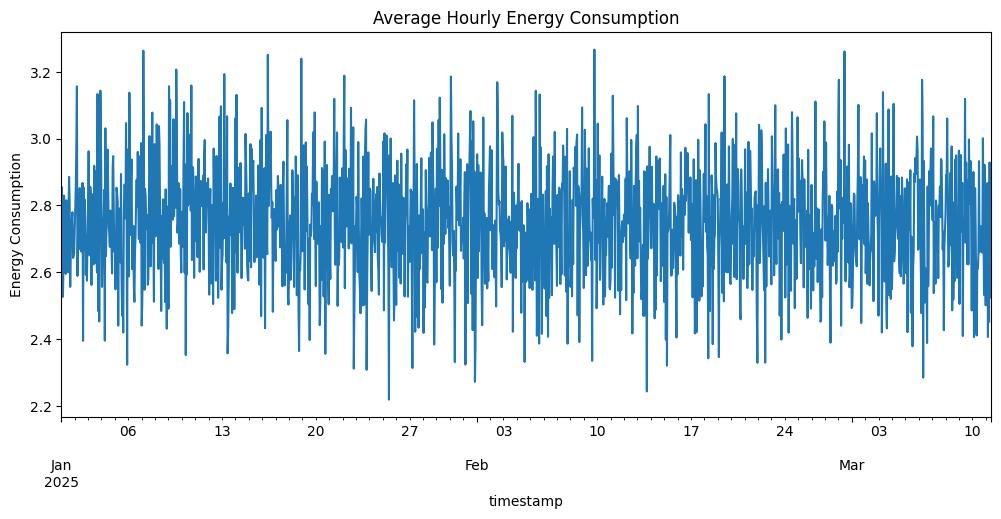

In [16]:
hourly_energy = (
    df
    .set_index("timestamp")
    ["energy_consumption"]
    .resample("h")
    .mean()
)

hourly_energy.plot(figsize=(12,5))

plt.title("Average Hourly Energy Consumption")
plt.ylabel("Energy Consumption")

plt.show()

In [26]:
anomalies_by_machine = (
    df.groupby("machine_id")["anomaly_flag"]
    .sum()
    .sort_values(ascending=False)
)

anomalies_by_machine.head(10)

machine_id
38    210
45    206
28    204
29    204
43    201
4     200
26    199
32    197
18    193
17    188
Name: anomaly_flag, dtype: int64